In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm

# ---------- (a) 生成資料 ----------
def generate_data(seed=1, n=100):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=n)
    y = x - 2*(x**2) + rng.normal(size=n)
    return x, y

x, y = generate_data(seed=1, n=100)
n = len(x); p = 1
print(f"(a) n = {n}, p = {p}")
print("Model: Y = X - 2*X^2 + epsilon, epsilon ~ N(0, 1)")

(a) n = 100, p = 1
Model: Y = X - 2*X^2 + epsilon, epsilon ~ N(0, 1)


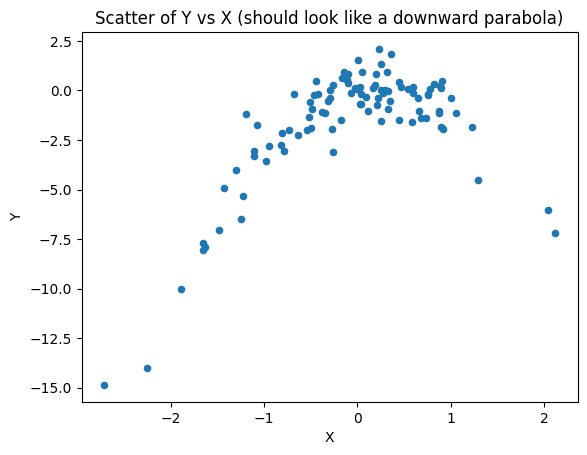

In [2]:
plt.figure()
plt.scatter(x, y, s=20)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter of Y vs X (should look like a downward parabola)")
plt.show()

In [3]:
def loocv_mse(x, y, degree):
    X = x.reshape(-1, 1)
    loo = LeaveOneOut()
    preds = np.zeros_like(y, dtype=float)

    # 用 sklearn 的 pipeline：多項式特徵 + 線性回歸
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                          LinearRegression())
    for i, (train_idx, test_idx) in enumerate(loo.split(X)):
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])

    return mean_squared_error(y, preds)

cv_results_seed1 = {d: loocv_mse(x, y, d) for d in [1, 2, 3, 4]}
print("\n(c) LOOCV MSE (seed=1, same dataset):")
for d, mse in cv_results_seed1.items():
    print(f"Degree {d}: MSE = {mse:.4f}")



(c) LOOCV MSE (seed=1, same dataset):
Degree 1: MSE = 6.6330
Degree 2: MSE = 1.1229
Degree 3: MSE = 1.3018
Degree 4: MSE = 1.3324


In [4]:
x2, y2 = generate_data(seed=2, n=100)
cv_results_seed2 = {d: loocv_mse(x2, y2, d) for d in [1, 2, 3, 4]}
print("\n(d) LOOCV MSE (seed=2, regenerated dataset):")
for d, mse in cv_results_seed2.items():
    print(f"Degree {d}: MSE = {mse:.4f}")
print("說明：如果不重生資料、只重設 random seed 來跑 LeaveOneOut，結果不會變；")
print("這裡我們改 seed 來『重生一套新資料』，因此數值可能改變，但趨勢通常相似。")

# ---------- (e) 哪個模型 MSE 最小 ----------
best_deg_seed1 = min(cv_results_seed1, key=cv_results_seed1.get)
print(f"\n(e) (seed=1) 最小 LOOCV MSE 來自 degree = {best_deg_seed1}。")
print("因為真實生成式是二次函數，通常 degree=2 會最優，這與預期一致。")


(d) LOOCV MSE (seed=2, regenerated dataset):
Degree 1: MSE = 7.5606
Degree 2: MSE = 0.9840
Degree 3: MSE = 0.9682
Degree 4: MSE = 0.9660
說明：如果不重生資料、只重設 random seed 來跑 LeaveOneOut，結果不會變；
這裡我們改 seed 來『重生一套新資料』，因此數值可能改變，但趨勢通常相似。

(e) (seed=1) 最小 LOOCV MSE 來自 degree = 2。
因為真實生成式是二次函數，通常 degree=2 會最優，這與預期一致。


In [5]:
def sm_ols_summary(x, y, degree):
    # 產生多項式設計矩陣（含截距）
    X = x.reshape(-1, 1)
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    X_poly = sm.add_constant(X_poly)  # 加入截距
    model = sm.OLS(y, X_poly).fit()
    print(f"\n(f) OLS Summary for degree={degree}")
    print(model.summary())
    return model

# 依序列出 1~4 次模型的 OLS 摘要（含 p-value）
for d in [1, 2, 3, 4]:
    _ = sm_ols_summary(x, y, d)

print("\n解讀建議：")
print("- degree=2 的一次項與二次項通常會顯著（因為真實模型就是二次）。")
print("- degree=1 常見欠擬合；degree=3/4 可能出現高階項不顯著（過度擬合）。")
print("- 係數顯著性與 LOOCV 最佳模型（二次）結論通常一致。")


(f) OLS Summary for degree=1
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.04e-09
Time:                        16:04:43   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650 